# Prediction Model Blueprint

Topic: Energy consumption prediction

Author: Ananya W.

Packages: pandas, scikit-learn, seaborn, matplotlib

Files: `blueprint_data_{train/unlabeled}.csv`

Ananya's work in this document is divided into 6 phases:
1. Data analysis
2. Data cleansing
3. Feature engineering
4. Dataset splitting
5. Model training and testing
6. Evaluation and encapsulation of the results


## 1. Data analysis
We start with a compact exploratory analysis to understand structure, ranges, and missing values.


Before we train any model, we first look at the data itself. This helps us see which columns are present, whether values look reasonable, and whether there are missing entries that we need to handle later.


In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

RANDOM_STATE = 23
TRAIN_FILE = "blueprint_data_train.csv"
UNLABELED_FILE = "blueprint_data_unlabeled.csv"

dataframe = pd.read_csv(TRAIN_FILE)
dataframe.head()


,job_id,route_len_m,elevation_delta_m,payload_kg,battery_soc,hour,congestion_flag,operation_mode,energy_kj
0,1,92.98,-0.2,3.23,0.910,3,high,standard,191.761
1,2,223.58,-0.3,2.16,0.866,15,high,standard,403.691
2,3,113.68,2.6,3.30,0.658,18,low,standard,312.856
3,4,45.13,-1.1,2.64,0.710,16,high,express,170.171
4,5,167.35,-1.5,3.48,0.514,8,low,express,387.059


In [2]:
dataframe.info()
dataframe.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_id             1500 non-null   int64  
 1   route_len_m        1500 non-null   float64
 2   elevation_delta_m  1500 non-null   float64
 3   payload_kg         1485 non-null   float64
 4   battery_soc        1485 non-null   float64
 5   hour               1500 non-null   int64  
 6   congestion_flag    1488 non-null   str    
 7   operation_mode     1500 non-null   str    
 8   energy_kj          1500 non-null   float64
dtypes: float64(5), int64(2), str(2)
memory usage: 105.6 KB


,job_id,route_len_m,elevation_delta_m,payload_kg,battery_soc,hour,congestion_flag,operation_mode,energy_kj
count,1500.000000,1500.000000,1500.000000,1485.000000,1485.000000,1500.000000,1488,1500,1500.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,low,standard,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1055,1230,NaN
mean,750.500000,126.527980,0.028533,2.556397,0.690447,11.352000,NaN,NaN,287.826047
std,433.157015,57.814766,1.930396,1.955292,0.182036,6.965087,NaN,NaN,113.265857
min,1.000000,16.250000,-5.200000,0.000000,0.165000,0.000000,NaN,NaN,33.973000
25%,375.750000,82.200000,-1.400000,0.930000,0.559000,6.000000,NaN,NaN,201.691500
50%,750.500000,122.210000,0.000000,2.390000,0.708000,11.000000,NaN,NaN,277.472000
75%,1125.250000,165.480000,1.400000,3.840000,0.838000,18.000000,NaN,NaN,361.188000


In [3]:
missing_summary = dataframe.isna().sum().sort_values(ascending=False)
missing_summary


battery_soc          15
payload_kg           15
congestion_flag      12
job_id                0
elevation_delta_m     0
route_len_m           0
hour                  0
operation_mode        0
energy_kj             0
dtype: int64

We create hisograms and count plots for all of the data's features individually to get a better idea of the value distributions.

Plots make patterns easier to see than tables alone. Histograms show how values are spread, and count plots show how often each category appears. This helps us understand which columns are numeric and which are categorical.

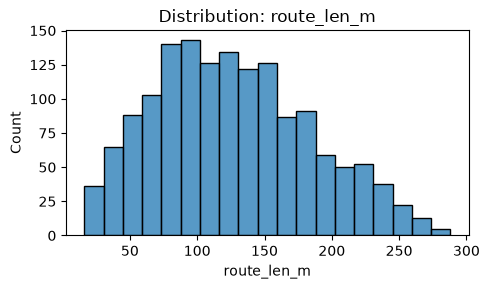

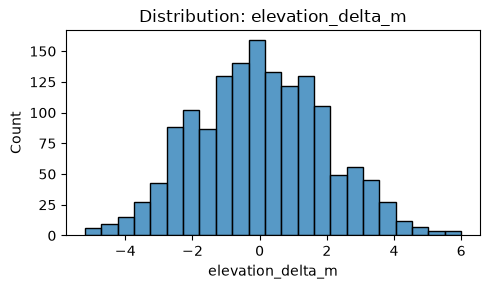

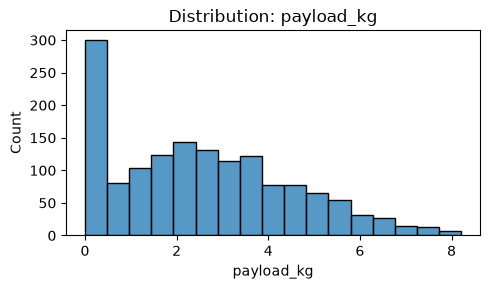

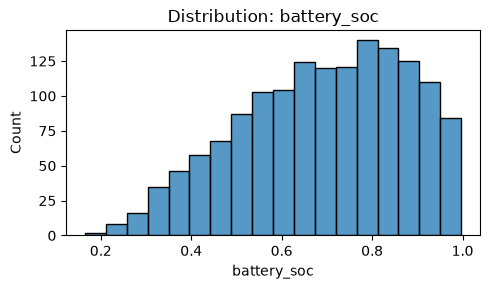

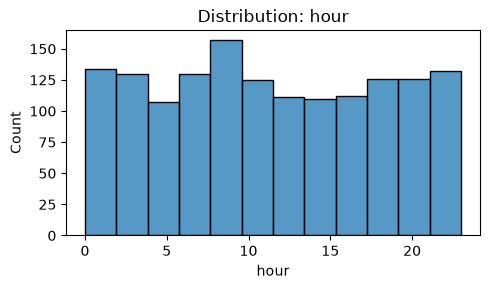

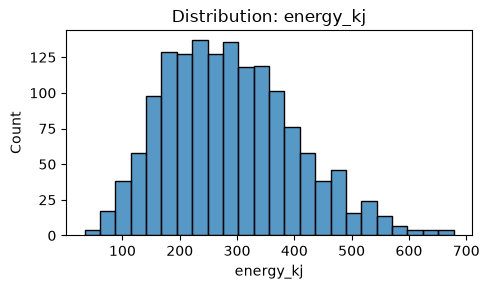

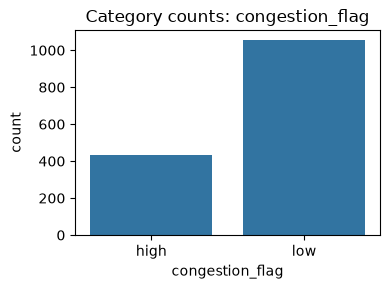

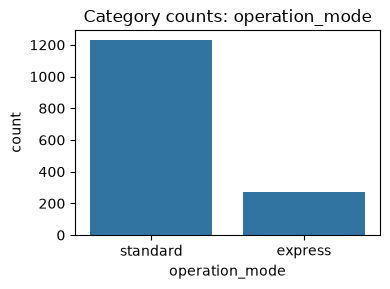

In [4]:
numeric_cols = ["route_len_m", "elevation_delta_m", "payload_kg", "battery_soc", "hour", "energy_kj"]
categorical_cols = ["congestion_flag", "operation_mode"]

for col in numeric_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(dataframe[col], kde=False)
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    plt.show()

for col in categorical_cols:
    plt.figure(figsize=(4, 3))
    sns.countplot(x=dataframe[col])
    plt.title(f"Category counts: {col}")
    plt.tight_layout()
    plt.show()


## 2. Data cleansing

For data preprocessing, we first need to consider how to interpret the columns, and which to use as features or as prediction targets.

From the information given regarding the prediction task, we know that the goal is to predict the energy consumption for each job. Thus, the target column is `energy_kj`.

The column `job_id` is a counter column used to uniquely identify each of the transport jobs. We do not assume a correlation to the prediction target `energy_kj`. Thus, the Job ID is not a feature which should be used as input for the prediction model.

All other columns in the dataset are either numeric or categorical columns, and could potentially be helpful to predict the job's energy consumption.
We will use them as features in our model training.
To allow for specific preprocessing, we will define variables to clearly distinguish numeric and categorical columns.

In [5]:
TARGET_COLUMN = "energy_kj"
ID_COLUMN = "job_id"
NUMERIC_COLUMNS = ["route_len_m", "elevation_delta_m", "payload_kg", "battery_soc", "hour"]
CATEGORICAL_COLUMNS = ["congestion_flag", "operation_mode"]

As found in the previous section, the dataset contains a small number of missing values.

One possible cleansing strategy would be to simply drop all rows with missing values.

But we heard that a more advanced strategy, which allows us to preserve all the data instances, is imputation.
Accordingly, we choose the following strategy:
- Numeric columns: fill missing values with the median from training data
- Categorical columns: fill missing values with the mode from training data (most prevalent categorical value)


In [6]:
def fit_imputer(df_train: pd.DataFrame):
    # Create dictionary with imputation values based on training data (median for numeric, mode for categorical)
    median_values = {col: df_train[col].median() for col in NUMERIC_COLUMNS}
    mode_values = {col: df_train[col].mode(dropna=True).iloc[0] for col in CATEGORICAL_COLUMNS}

    # Define a function that applies the imputation to any given DataFrame
    def apply_imputation(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        for col, value in median_values.items():
            out[col] = out[col].fillna(value)
        for col, value in mode_values.items():
            out[col] = out[col].fillna(value)
        return out

    return apply_imputation


## 3. Feature engineering

As most models require numeric values for input features, we need to transform the categorical features first.

One commonly used approach is to one-hot encode categorical features:

In one-hot encoding, a new column (feature) is created for every category present in the data. 
For each row of data, the values of these new columns are set as follows:
* Set column value to `1` if the category in the original column corresponds to the category indicated by the newly created column
* Otherwise, set column value to `0` 

Categorical features can be one-hot encoded using the pandas function `get_dummies`.


In [7]:
def fit_preprocessor(df_train: pd.DataFrame):
    impute_fn = fit_imputer(df_train)

    # Define a function that applies both imputation and one-hot encoding to any given DataFrame
    def transform(df: pd.DataFrame) -> pd.DataFrame:
        imputed_df = impute_fn(df)
        output_df = pd.get_dummies(imputed_df, columns=CATEGORICAL_COLUMNS, drop_first=False)
        return output_df

    return transform


## 4. Dataset splitting


We now split the labeled data into two parts: one part for training the model and one part for checking how well it works on unseen data. This is important because a model can look good on the training data even if it would not work well on new examples.


In [14]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(dataframe, test_size=0.25, random_state=RANDOM_STATE)
transform_data_fn = fit_preprocessor(train_df)

train_proc = transform_data_fn(train_df)
test_proc = transform_data_fn(test_df)
test_proc = test_proc.reindex(columns=train_proc.columns, fill_value=0)

feature_columns = [c for c in train_proc.columns if c not in [TARGET_COLUMN, ID_COLUMN]]
X_train = train_proc[feature_columns]
y_train = train_proc[TARGET_COLUMN]
X_test = test_proc[feature_columns]
y_test = test_proc[TARGET_COLUMN]

print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Number of model features: {len(feature_columns)}")


Train rows: 1125
Test rows: 375
Number of model features: 9


We can now also investigate the preprocessed training (or test) data to see the results of the performed preprocessing steps.

In [ ]:
train_proc.head()

In [ ]:
test_proc.head()

## 5. Model training and testing
We compare four regression models and evaluate them on unseen test data.


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor


# Define a set of regression models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=4, include_bias=False)),
        ("linreg", LinearRegression())
    ]),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
}

def train_and_evaluate(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    result = {"Model": name, "MAE": mae, "MSE": mse}
    return model, result

trained_models = {}
results = []

for model_name, model in models.items():
    trained_model, metrics = train_and_evaluate(model_name, model, X_train, y_train, X_test, y_test)
    trained_models[model_name] = trained_model
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by="MSE")
results_df


,Model,MAE,MSE
3,Random Forest,21.194337,756.575070
1,Polynomial Regression,27.406727,1179.715403
2,Decision Tree,36.888104,2353.706310
0,Linear Regression,40.195431,2440.903766


In [18]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best model (by MSE): {best_model_name}")


Best model (by MSE): Random Forest


## 6. Evaluation and encapsulation of the results

We define functions for data preprocessing and prediction logic, so the code can be reused to create predictions for unlabeled datasets.


In [24]:
def preprocess_for_model(df: pd.DataFrame, transform_fn):
    proc = transform_fn(df)
    X = proc[feature_columns]
    return proc, X

def run_on_dataset(dataset_path: str, model, transform_fn):
    dataset_df = pd.read_csv(dataset_path)
    dataset_proc, X_dataset = preprocess_for_model(dataset_df, transform_fn)
    predictions = model.predict(X_dataset)

    output = pd.DataFrame({ID_COLUMN: dataset_proc[ID_COLUMN], "pred_energy_kj": predictions})
    return output


We now use the function defined above to create predictions for the unlabelled dataset.

In [23]:
unlabeled_predictions = run_on_dataset(UNLABELED_FILE, best_model, transform_data_fn)
unlabeled_predictions.head()


,job_id,pred_energy_kj
0,1,250.214840
1,2,473.111125
2,3,295.468385
3,4,485.185730
4,5,365.088440


For later evaluation, we store the predictions for the unlabeled data, as produced by our model, to a new csv file.


In [22]:
OUTPUT_PREDICTION_FILE = "blueprint_predictions_unlabeled.csv"
unlabeled_predictions.to_csv(OUTPUT_PREDICTION_FILE, index=False)
print(f"Saved prediction file: {OUTPUT_PREDICTION_FILE}")


Saved prediction file: blueprint_predictions_unlabeled.csv


### A message from Ananya
I hope this blueprint still gives your team a clear structure for solving the new data challenge.

Even if the new dataset differs from this one, the workflow should transfer well:
understand data, clean consistently, train multiple models, compare fairly, and evaluate on unseen data.

We also think that there is a chance the results could be further improved by trying different models or hyperparameters.

Good luck and have fun experimenting!
